In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

import schwingerModel as sim

In [30]:
m = .2
a = 1
dimx = 32
dimt = 64
beta = 10
totalSteps = 100

In [31]:
models = []

subSteps = (np.geomspace(1,50,16)).astype(int)

models = Parallel(n_jobs=-1)(delayed(sim.schwingerModel)(metroSteps=totalSteps,beta=beta,dimx=dimx,dimt=dimt,aSpacing=a,fMass=m,cgRtol=1e-5,numSubSteps=subSteps[i],tqdmPosition=i) for i in range(len(subSteps)))

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]








  0%|          | 0/100 [00:00<?, ?it/s]





  0%|          | 0/100 [00:00<?, ?it/s]








  0%|          | 0/100 [00:00<?, ?it/s]









  0%|          | 0/100 [00:00<?, ?it/s]












  0%|          | 0/100 [00:00<?, ?it/s]











  0%|          | 0/100 [00:00<?, ?it/s]






  0%|          | 0/100 [00:00<?, ?it/s]


  0%|          | 0/100 [00:00<?, ?it/s]







  0%|          | 0/100 [00:00<?, ?it/s]










  0%|          | 0/100 [00:00<?, ?it/s]




























  4%|▍         | 4/100 [00:00<00:02, 39.39it/s]

  4%|▍         | 4/100 [00:00<00:02, 39.49it/s]




  3%|▎         | 3/100 [00:00<00:03, 26.70it/s]








  1%|          | 1/100 [00:00<00:11,  8.30it/s]



  4%|▍         | 4/100 [00:00<00:02, 32.03it/s]


  4%|▍         | 4/100 [00:00<00:03, 31.90it/s]









  1%|          | 1/100 [00:00<00:13,  7.18it/s]





  3%|▎         | 3/100 [00:00<00:04, 20.58it/

In [32]:
aFracs = []
for mod in models:
    aFrac = sim.analysis.acceptanceFraction(mod)
    aFracs.append(aFrac)
aFrac = np.array(aFrac)

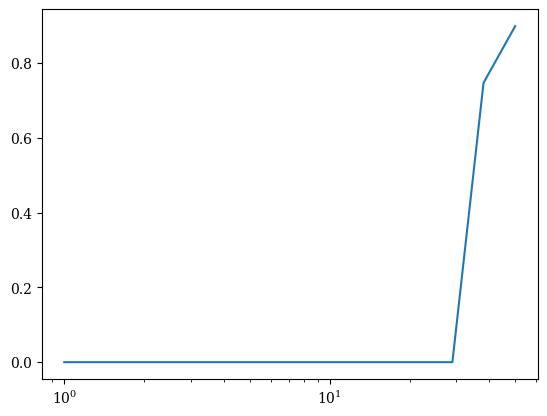

In [33]:
plt.semilogx(subSteps,aFracs)

In [38]:
subSteps[-2]

np.int64(38)

In [39]:
sim.analysis.acceptanceFraction(models[-2])

np.float64(0.7474747474747475)

In [40]:
correl = sim.distillation.correlStats(models[-1],burnIn=5,autocorrSkip=3)

configs:   0%|          | 0/32 [00:00<?, ?it/s]

In [41]:
sim.distillation.correlMassExtract(correl,fitT=[3,18],diagCov=True)

array([0.54862685, 0.0008332 ])